In [1]:
#Task 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('q3_retail_promotions.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

print(f"Dataset shape: {df.shape}")
print(f"Date range   : {df['transaction_date'].min().date()} → {df['transaction_date'].max().date()}")
print(f"\nOriginal columns: {list(df.columns)}")

Dataset shape: (1200, 9)
Date range   : 2022-01-01 → 2024-12-31

Original columns: ['transaction_date', 'store_id', 'store_size', 'location_type', 'promotion_type', 'is_weekend', 'is_festival', 'competition_density', 'items_sold']


In [2]:
df['year']        = df['transaction_date'].dt.year
df['month']       = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek          # 0=Monday … 6=Sunday
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("New date-derived columns added: year, month, day_of_week, is_month_end")
print(f"\nis_month_end distribution:")
print(df['is_month_end'].value_counts().rename({0: 'Not month-end (day < 25)',
                                                 1: 'Month-end    (day ≥ 25)'}))

print("\nSample of dataframe with new features:")
df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end',
    'items_sold']].head(10)

New date-derived columns added: year, month, day_of_week, is_month_end

is_month_end distribution:
is_month_end
Not month-end (day < 25)    959
Month-end    (day ≥ 25)     241
Name: count, dtype: int64

Sample of dataframe with new features:


,transaction_date,year,month,day_of_week,is_month_end,items_sold
0,2022-01-01,2022,1,5,0,224
1,2022-01-01,2022,1,5,0,348
2,2022-01-02,2022,1,6,0,249
3,2022-01-02,2022,1,6,0,259
4,2022-01-03,2022,1,0,0,277
5,2022-01-03,2022,1,0,0,411
6,2022-01-04,2022,1,1,0,193
7,2022-01-04,2022,1,1,0,240
8,2022-01-05,2022,1,2,0,305
9,2022-01-05,2022,1,2,0,181


In [3]:
#Task 2
df = df.sort_values('transaction_date').reset_index(drop=True)

split_idx = int(len(df) * 0.80)
train_df  = df.iloc[:split_idx].copy()
test_df   = df.iloc[split_idx:].copy()

print(f"Total records : {len(df)}")
print(f"Train records : {len(train_df)}  "
      f"({train_df['transaction_date'].min().date()} → {train_df['transaction_date'].max().date()})")
print(f"Test  records : {len(test_df)}   "
      f"({test_df['transaction_date'].min().date()} → {test_df['transaction_date'].max().date()})")
print(f"\nTrain/Test split: {len(train_df)/len(df)*100:.1f}% / {len(test_df)/len(df)*100:.1f}%")

Total records : 1200
Train records : 960  (2022-01-01 → 2024-06-11)
Test  records : 240   (2024-06-12 → 2024-12-31)

Train/Test split: 80.0% / 20.0%


In [4]:
#Task 3
categorical_cols = ['promotion_type', 'location_type', 'store_size']
numerical_cols   = ['store_id', 'is_weekend', 'is_festival',
                    'competition_density', 'year', 'month',
                    'day_of_week', 'is_month_end']
target_col       = 'items_sold'

X_train = train_df[categorical_cols + numerical_cols]
y_train = train_df[target_col]
X_test  = test_df[categorical_cols + numerical_cols]
y_test  = test_df[target_col]

print("Feature summary:")
print(f"  Categorical ({len(categorical_cols)}) : {categorical_cols}")
print(f"  Numerical   ({len(numerical_cols)}) : {numerical_cols}")
print(f"\nX_train shape: {X_train.shape} | X_test shape: {X_test.shape}")

Feature summary:
  Categorical (3) : ['promotion_type', 'location_type', 'store_size']
  Numerical   (8) : ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']

X_train shape: (960, 11) | X_test shape: (240, 11)


In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_cols),
        ('scl', StandardScaler(), numerical_cols),
    ],
    remainder='drop'
)

preprocessor.fit(X_train)

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

ohe_feature_names = (preprocessor
                     .named_transformers_['ohe']
                     .get_feature_names_out(categorical_cols).tolist())
all_feature_names = ohe_feature_names + numerical_cols

print(f"Transformed training matrix shape : {X_train_transformed.shape}")
print(f"Transformed test matrix shape     : {X_test_transformed.shape}")
print(f"Total features after encoding     : {len(all_feature_names)}")
print(f"\nOne-hot encoded columns ({len(ohe_feature_names)}):")
for c in ohe_feature_names:
    print(f"  {c}")

Transformed training matrix shape : (960, 19)
Transformed test matrix shape     : (240, 19)
Total features after encoding     : 19

One-hot encoded columns (11):
  promotion_type_bogo
  promotion_type_category_offer
  promotion_type_flat_discount
  promotion_type_free_gift
  promotion_type_loyalty_points
  location_type_rural
  location_type_semi-urban
  location_type_urban
  store_size_large
  store_size_medium
  store_size_small


In [6]:
#Task 4
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Train — preprocessor is re-fit as part of the pipeline on X_train
pipe_lr.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)

print("Both pipelines trained successfully.")
print(f"  Linear Regression     — {pipe_lr.named_steps['model'].__class__.__name__}")
print(f"  Random Forest         — {pipe_rf.named_steps['model'].__class__.__name__} "
      f"(n_estimators=100, random_state=42)")

Both pipelines trained successfully.
  Linear Regression     — LinearRegression
  Random Forest         — RandomForestRegressor (n_estimators=100, random_state=42)


In [7]:
y_pred_lr = pipe_lr.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)

metrics = {
    'Linear Regression' : {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        'MAE' : mean_absolute_error(y_test, y_pred_lr),
    },
    'Random Forest' : {
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        'MAE' : mean_absolute_error(y_test, y_pred_rf),
    },
}

metrics_df = pd.DataFrame(metrics).T.round(3)
print("Test-set performance metrics:")
print(metrics_df.to_string())

Test-set performance metrics:
                     RMSE     MAE
Linear Regression  27.121  21.053
Random Forest      30.842  24.241


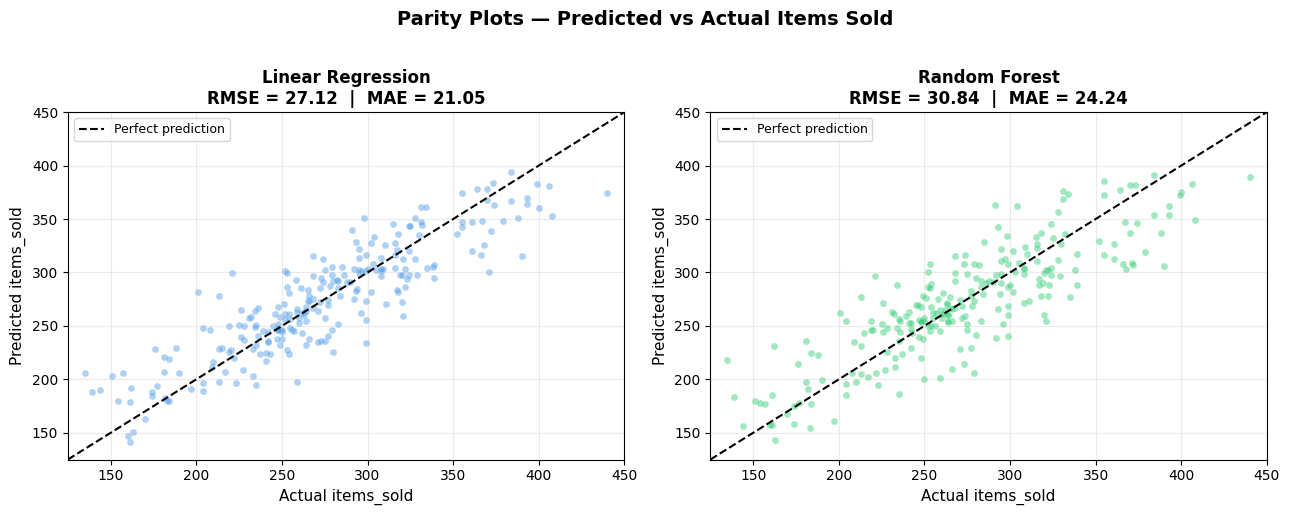

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, y_pred, color) in zip(
    axes,
    [('Linear Regression', y_pred_lr, '#4C9BE8'),
     ('Random Forest',     y_pred_rf, '#2ECC71')]
):
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)

    ax.scatter(y_test, y_pred, alpha=0.45, s=25, c=color,
               edgecolors='white', linewidths=0.3)

    # Perfect-prediction diagonal
    lims = [min(y_test.min(), y_pred.min()) - 10,
            max(y_test.max(), y_pred.max()) + 10]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect prediction')

    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(f'{name}\nRMSE = {rmse:.2f}  |  MAE = {mae:.2f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual items_sold', fontsize=11)
    ax.set_ylabel('Predicted items_sold', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25)

plt.suptitle('Parity Plots — Predicted vs Actual Items Sold', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plot_parity.png', dpi=120)
plt.show()

In [9]:
ohe_cols = (pipe_rf.named_steps['preprocessor']
                   .named_transformers_['ohe']
                   .get_feature_names_out(categorical_cols).tolist())
feat_names = ohe_cols + numerical_cols

importances = pipe_rf.named_steps['model'].feature_importances_
feat_imp = (pd.Series(importances, index=feat_names)
              .sort_values(ascending=False)
              .reset_index())
feat_imp.columns = ['Feature', 'Importance']

print("Random Forest Feature Importances (all features):")
print(feat_imp.to_string(index=False))

print(f"\nTop 5 most influential features:")
print(feat_imp.head(5).to_string(index=False))

Random Forest Feature Importances (all features):
                      Feature  Importance
                  is_festival    0.173473
             store_size_small    0.167683
          location_type_urban    0.108378
                  day_of_week    0.086316
                   is_weekend    0.061208
                     store_id    0.054882
          location_type_rural    0.053794
             store_size_large    0.051113
          competition_density    0.050805
                        month    0.037383
          promotion_type_bogo    0.030311
            store_size_medium    0.027020
promotion_type_loyalty_points    0.023142
     location_type_semi-urban    0.017195
                         year    0.017154
 promotion_type_flat_discount    0.015956
promotion_type_category_offer    0.010776
     promotion_type_free_gift    0.008061
                 is_month_end    0.005350

Top 5 most influential features:
            Feature  Importance
        is_festival    0.173473
   store_siz

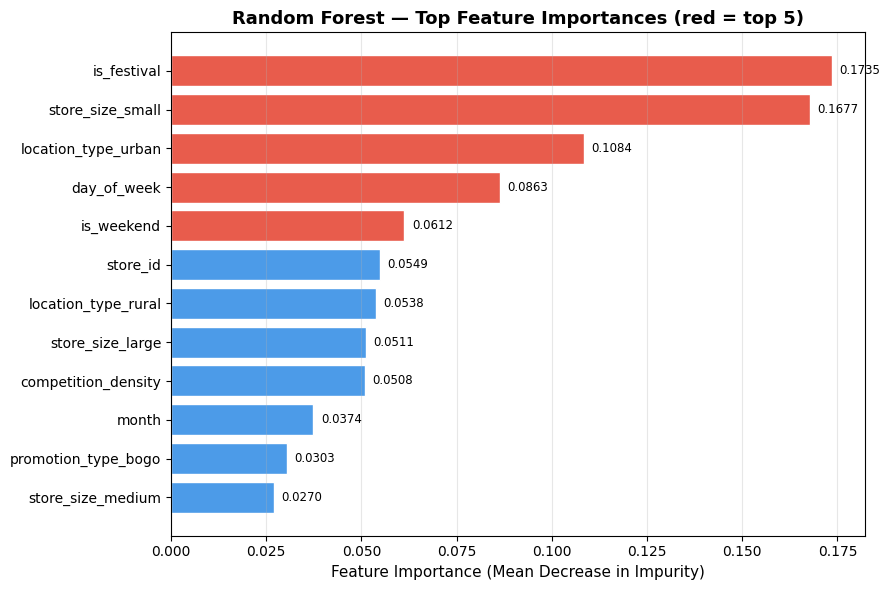

In [10]:
top_n = 12
top_feat = feat_imp.head(top_n)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#E85C4C' if i < 5 else '#4C9BE8' for i in range(top_n)]
bars = ax.barh(top_feat['Feature'][::-1], top_feat['Importance'][::-1],
               color=colors[::-1], edgecolor='white')

ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Random Forest — Top Feature Importances (red = top 5)',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, top_feat['Importance'][::-1]):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=120)
plt.show()